In [1]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
print("Tensorflow Version: ", tf.__version__)
print("Keras Version: ", keras.__version__)
print("Numpy Version: ", np.__version__)

Tensorflow Version:  2.18.0
Keras Version:  3.8.0
Numpy Version:  1.26.4


In [3]:
labels = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

def load_train_data():
    train_set = image_dataset_from_directory(
        directory='./data/seg_train',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return train_set

def load_pred_data():
    pred_set = image_dataset_from_directory(
        directory='./data/seg_pred',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return pred_set

def load_test_data():
    test_set = image_dataset_from_directory(
        directory='./data/seg_test',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return test_set

train_set = load_train_data()
# pred_set = load_pred_data()
test_set = load_test_data()

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


#### This is really cool and much better than having to make my own function for this.

In [4]:
train_set = load_train_data()
# pred_set = load_pred_data()
test_set = load_test_data()

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [5]:
for images, labels in train_set.take(1):
    print("Images shape:", images.shape)  # (batch_size, 256, 256, 3)
    print("Labels shape:", labels.shape)  # (batch_size, num_classes)

Images shape: (32, 256, 256, 3)
Labels shape: (32, 6)


2025-02-22 00:50:59.373051: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
train_dir = "./data/seg_train"
# val_dir = "./data/seg_pred"
test_dir = "./data/seg_test"

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                  train_dir, target_size=(150,150), batch_size=20, class_mode='categorical') 

# val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# val_generator = val_datagen.flow_from_directory(
#                     val_dir, target_size=(150,150), batch_size=20, class_mode='categorical')

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
                  test_dir,target_size = (150,150),batch_size=20,class_mode='categorical') 

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [7]:
class_names = train_set.class_names
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

2025-02-22 00:50:59.962552: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


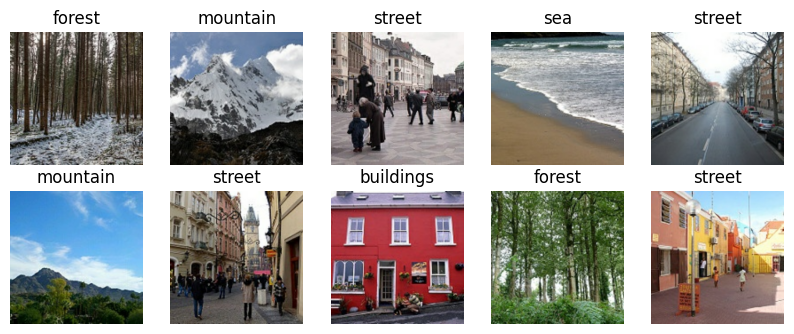

In [8]:
plt.figure(figsize=(10,10))
for images, labels in train_set.take(1):
    for i in range(10):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"));
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

In [9]:
class_counts = {}
for class_name in os.listdir('./data/seg_train'):
    class_dir = os.path.join('./data/seg_train', class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))
for class_name, count in class_counts.items():
    print(f'{class_name}: {count} images')

forest: 2271 images
buildings: 2191 images
glacier: 2404 images
street: 2382 images
mountain: 2512 images
sea: 2274 images


Text(0, 0.5, 'Number of images')

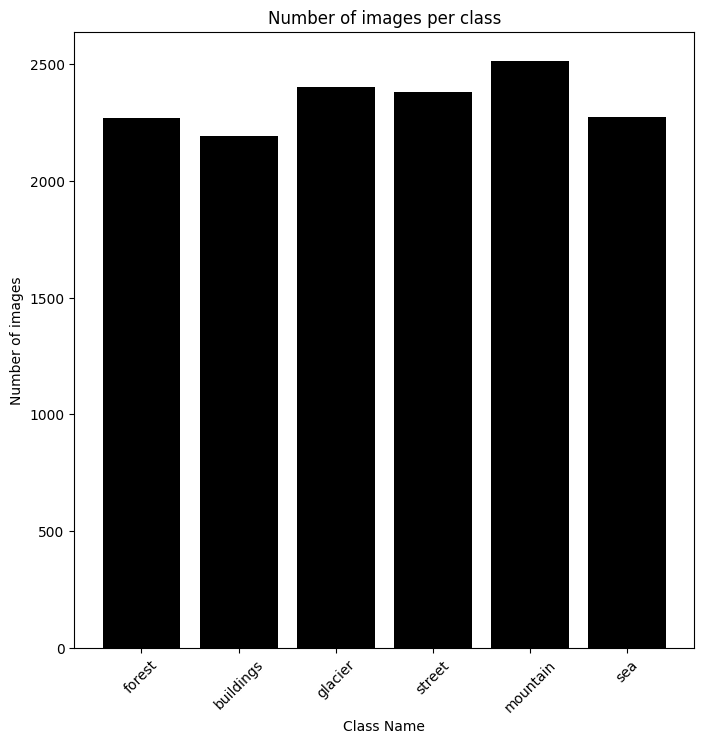

In [10]:
plt.figure(figsize=(8,8))
plt.bar(class_counts.keys(), class_counts.values(), color='black');
plt.title('Number of images per class')
plt.xticks(rotation=45)
plt.xlabel('Class Name')
plt.ylabel('Number of images')

#### Intel's dataset wasn't stratified by class name 😔

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(6,activation='softmax')
])
model.summary()

/Users/aydelottec/Desktop/CodingProjects/NeuralNetworks/Intel-Image-Classification/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,294 (12.64 MB)

 Trainable params: 3,312,294 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [13]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    validation_steps=50,
    steps_per_epoch=50,
    epochs=1000,
    verbose=2
)

Epoch 1/1000


/Users/aydelottec/Desktop/CodingProjects/NeuralNetworks/Intel-Image-Classification/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 - 5s - 94ms/step - accuracy: 0.4250 - loss: 1.4522 - val_accuracy: 0.5050 - val_loss: 1.2369
Epoch 2/1000
50/50 - 4s - 82ms/step - accuracy: 0.5490 - loss: 1.1304 - val_accuracy: 0.5850 - val_loss: 1.0504
Epoch 3/1000
50/50 - 4s - 81ms/step - accuracy: 0.5530 - loss: 1.0935 - val_accuracy: 0.5670 - val_loss: 1.0528
Epoch 4/1000
50/50 - 4s - 80ms/step - accuracy: 0.6110 - loss: 0.9799 - val_accuracy: 0.6780 - val_loss: 0.9217
Epoch 5/1000
50/50 - 4s - 80ms/step - accuracy: 0.6180 - loss: 0.9791 - val_accuracy: 0.6490 - val_loss: 0.8782
Epoch 6/1000
50/50 - 4s - 81ms/step - accuracy: 0.6900 - loss: 0.8435 - val_accuracy: 0.6420 - val_loss: 0.9054
Epoch 7/1000
50/50 - 4s - 81ms/step - accuracy: 0.6640 - loss: 0.8876 - val_accuracy: 0.6400 - val_loss: 0.9362
Epoch 8/1000
50/50 - 4s - 81ms/step - accuracy: 0.6770 - loss: 0.8243 - val_accuracy: 0.7210 - val_loss: 0.7925
Epoch 9/1000
50/50 - 4s - 80ms/step - accuracy: 0.6840 - loss: 0.7980 - val_accuracy: 0.6550 - val_loss: 0.8656
Epoch

/Users/aydelottec/Desktop/CodingProjects/NeuralNetworks/Intel-Image-Classification/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 - 1s - 23ms/step - accuracy: 0.6750 - loss: 0.8453 - val_accuracy: 0.7230 - val_loss: 0.7335
Epoch 16/1000
50/50 - 5s - 94ms/step - accuracy: 0.7700 - loss: 0.6414 - val_accuracy: 0.7750 - val_loss: 0.6563
Epoch 17/1000
50/50 - 4s - 84ms/step - accuracy: 0.7570 - loss: 0.6705 - val_accuracy: 0.7470 - val_loss: 0.6673
Epoch 18/1000
50/50 - 4s - 83ms/step - accuracy: 0.7910 - loss: 0.5985 - val_accuracy: 0.7460 - val_loss: 0.6799
Epoch 19/1000
50/50 - 4s - 83ms/step - accuracy: 0.7770 - loss: 0.6429 - val_accuracy: 0.7330 - val_loss: 0.7215
Epoch 20/1000
50/50 - 4s - 83ms/step - accuracy: 0.7730 - loss: 0.6178 - val_accuracy: 0.7440 - val_loss: 0.7131
Epoch 21/1000
50/50 - 4s - 81ms/step - accuracy: 0.7650 - loss: 0.6147 - val_accuracy: 0.7880 - val_loss: 0.6138
Epoch 22/1000
50/50 - 4s - 81ms/step - accuracy: 0.8008 - loss: 0.5245 - val_accuracy: 0.7620 - val_loss: 0.6764
Epoch 23/1000
50/50 - 4s - 82ms/step - accuracy: 0.8190 - loss: 0.5056 - val_accuracy: 0.7820 - val_loss: 0.61

In [16]:
train_accuracy = history.history['accuracy'][-1]
test_accuracy = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%, Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 98.20%, Test Accuracy: 78.00%


In [19]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(6,activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=test_generator,
    validation_steps=50,
    steps_per_epoch=50,
    epochs=1000,
    verbose=2
)

train_accuracy = history.history['accuracy'][-1]
test_accuracy = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%, Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/1000
50/50 - 5s - 103ms/step - accuracy: 0.3580 - loss: 1.5976 - val_accuracy: 0.5340 - val_loss: 1.2868
Epoch 2/1000
50/50 - 4s - 83ms/step - accuracy: 0.5150 - loss: 1.2067 - val_accuracy: 0.5510 - val_loss: 1.1453
Epoch 3/1000
50/50 - 4s - 83ms/step - accuracy: 0.5390 - loss: 1.1506 - val_accuracy: 0.5460 - val_loss: 1.1264
Epoch 4/1000
50/50 - 4s - 80ms/step - accuracy: 0.5650 - loss: 1.0922 - val_accuracy: 0.5640 - val_loss: 1.0986
Epoch 5/1000
50/50 - 4s - 81ms/step - accuracy: 0.5850 - loss: 1.0811 - val_accuracy: 0.5820 - val_loss: 1.0473
Epoch 6/1000
50/50 - 4s - 82ms/step - accuracy: 0.5920 - loss: 1.0356 - val_accuracy: 0.6210 - val_loss: 1.0203
Epoch 7/1000
50/50 - 4s - 82ms/step - accuracy: 0.6400 - loss: 0.9995 - val_accuracy: 0.5930 - val_loss: 1.0263
Epoch 8/1000
50/50 - 4s - 83ms/step - accuracy: 0.6070 - loss: 0.9940 - val_accuracy: 0.6380 - val_loss: 1.0147
Epoch 9/1000
50/50 - 4s - 81ms/step - accuracy: 0.6480 - loss: 0.9688 - val_accuracy: 0.6120 - val_loss

#### Overfitting like crazy

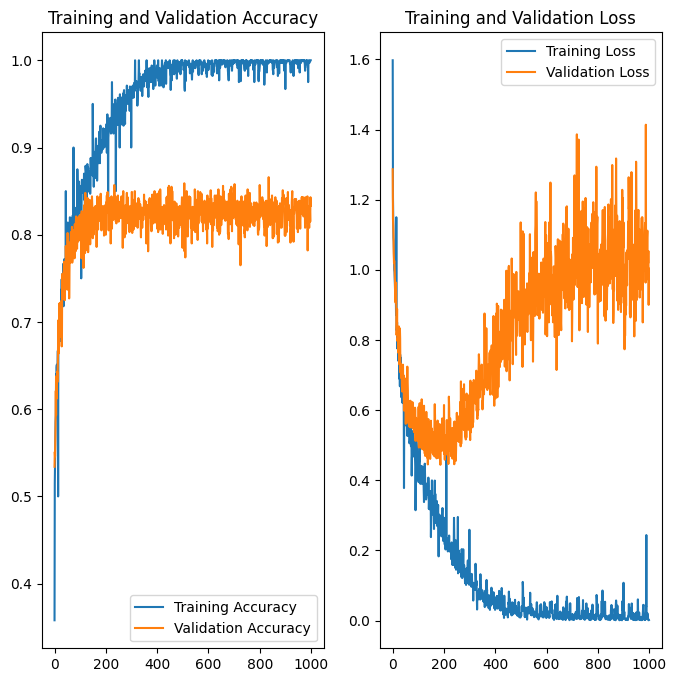

In [20]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

- Seems like 220 epochs is the sweet spot here.